# MINTverse in one district

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CosmoNaught/MINTverse/blob/main/MINTverse-tutorial.ipynb)

MINTverse is two Python packages, and one call, `run_scenarios`, chains them.

| Package | Import | What it does |
|---|---|---|
| estiMINT | `estimint` | Maps a measured prevalence to the entomological inoculation rate (EIR). |
| stateMINT | `stateMINT` | Emulates the individual-based model. Given a setting and an intervention package, returns the prevalence and case trajectories over the campaign. |

We take one district from a measured prevalence through to a plotted trajectory, a table of the
cases each campaign averts, and a pair of CSVs. It is the same material as chapters 4 to 6 of the
[documentation](https://cosmonaught.github.io/MINTverse), in a form you can run and edit in place.

## Setup

`pip install estimint mintstate` installs both packages, though the distribution is called
`mintstate` while the module you import is `stateMINT`. Both need Python 3.12 or newer.

A cell containing `!pip install estimint` shells out to whatever `pip` is first on the `PATH` of the
process that launched the notebook, and that is frequently not the environment the kernel runs in.
The cell below addresses the kernel's own interpreter explicitly instead, through `sys.executable`,
and skips the install altogether when the packages are already there.

Note that `mintstate` requires NumPy 2.4 and pandas 3.0, which are newer than the versions Colab
ships, so pip upgrades both and Colab then offers to restart the session. Accept the restart and run
the cell again. The install has to happen before NumPy or pandas is imported, which is why it comes
first.

In [1]:
import importlib.util
import sys

if importlib.util.find_spec("estimint") is None:
    !{sys.executable} -m pip install -q estimint mintstate matplotlib

The emulator weights, about 38 MB per predictor, download once from
[Hugging Face](https://huggingface.co/dide-ic/stateMINT) and are then cached. The first run is the
slow one. Colab starts from a cold cache every session and pays that download each time.

Three lines of housekeeping open the imports cell. XGBoost warns that the estiMINT models were
pickled by an earlier version of itself, JAX warns that it has fallen back to the CPU, and Hugging
Face draws a progress bar for the download. None of the three bears on the results, so the cell turns
them off before the imports run. The emulator is a CPU model, at about 6 ms per scenario in a batch,
so a GPU runtime buys nothing here.

In [2]:
import os

# Quieten three notices that would otherwise fill the output. None affects the result.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")   # the weights-download progress bar

import logging
import warnings

logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)   # the CPU fallback notice
warnings.filterwarnings("ignore", message=r".*serialized model.*")  # the XGBoost pickle notice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estimint import Scenario, EirTarget, run_scenarios, preload_models

# The palette the documentation plots with.
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=["#3987e5", "#199e70", "#c98500",
                                         "#9085e9", "#e66767", "#d55181"]),
    "figure.figsize": (7.6, 4.0),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.8,
    "legend.frameon": False,
})

## Constructing the scenarios

A `Scenario` describes one setting and one campaign, and `run_scenarios` takes a list of them and
returns a table with one row each. The district below sits at under-5 prevalence 0.45, pyrethroid
resistance 0.30, and pyrethroid-only nets at 0.70 coverage, where `EirTarget(0.45, "prevalence")`
tells `run_scenarios` that 0.45 is a measured prevalence rather than an EIR. That prevalence is
inverted into a baseline EIR first. The emulator never sees it.

Five campaigns are run against that one setting.

- Withdraw the nets. No campaign at all, which is the counterfactual the other four are measured against.
- Replace like for like, with pyrethroid-only nets at the same 0.70 coverage.
- Switch to PBO, again at 0.70.
- Switch to pyrrole, again at 0.70.
- PBO, plus IRS at 0.60 and LSM at 0.30.

The shared fields go in a dictionary, and each `Scenario` picks them up with `**district`, an idiom R
writes as `do.call(Scenario, c(district, list(name = "PBO", ...)))`. Every scenario therefore carries
the same setting. Any difference between the rows is caused by the campaign alone.

In [3]:
district = dict(
    res_use=0.30,      # pyrethroid resistance
    Q0=0.85,           # share of bites taken on humans
    phi=0.80,          # share of bites taken in bed
    seasonal=0.0,      # 0 perennial, 1 strongly seasonal
    irs=0.0,           # current IRS coverage
    py_only=0.70,      # the nets in place today
    routine=0.0,
    eir_target=EirTarget(0.45, "prevalence"),
)

scenarios = [
    Scenario(name="Withdraw", **district),
    Scenario(name="Pyrethroid-only", itn_future=0.70,
             net_type_future="pyrethroid_only", **district),
    Scenario(name="PBO", itn_future=0.70,
             net_type_future="pyrethroid_pbo", **district),
    Scenario(name="Pyrrole", itn_future=0.70,
             net_type_future="pyrethroid_pyrrole", **district),
    Scenario(name="PBO + IRS + LSM", itn_future=0.70,
             net_type_future="pyrethroid_pbo", irs_future=0.60, lsm=0.30, **district),
]

len(scenarios)

5

Note that `itn_future=0.70` does not mean "keep the nets you have". Leave it out and both
`dn0_future` and `itn_future` are set to zero, which models the nets being withdrawn at the
campaign, and `irs_future` does not inherit `irs` either. Every intervention you want to persist
past the campaign has to be restated in its `_future` field. The first scenario omits them
deliberately. It is also what results if a campaign is simply forgotten.

Note that `net_type_future` accepts `"pyrethroid_pbo"` or the short alias `"py_pbo"`, and does not
accept `"pyrethroid-pbo"`. A hyphen raises `ValueError: unknown net type`.

Transmission does not have to enter as a prevalence. `EirTarget(250_000.0, "hbr")` takes a human
biting rate from entomological trapping, and `EirTarget(20.0, "eir")` takes an EIR that is already
in hand, in which case estiMINT does nothing.

## Running them

`run_scenarios` converts each net mix and resistance level to `dn0`, inverts each measured
prevalence to a baseline EIR, and calls the emulator once with the whole batch. Five scenarios cost
barely more than one.

In [4]:
results = run_scenarios(scenarios)

results[["name", "net_future", "dn0_use", "dn0_future", "itn_future",
         "irs_future", "lsm", "eir_baseline", "prev_y9", "prev_endline"]].round(3)

,name,net_future,dn0_use,dn0_future,itn_future,irs_future,lsm,eir_baseline,prev_y9,prev_endline
0,Withdraw,none,0.311,0.000,0.0,0.0,0.0,31.96,0.456,0.498
1,Pyrethroid-only,pyrethroid_only,0.311,0.311,0.7,0.0,0.0,31.96,0.456,0.484
2,PBO,pyrethroid_pbo,0.311,0.485,0.7,0.0,0.0,31.96,0.456,0.470
3,Pyrrole,pyrethroid_pyrrole,0.311,0.550,0.7,0.0,0.0,31.96,0.456,0.464
4,PBO + IRS + LSM,pyrethroid_pbo,0.311,0.485,0.7,0.6,0.3,31.96,0.456,0.038


All five share the same `dn0_use`, the same `eir_baseline` of about 32 infectious bites per person
per year, and a `prev_y9` of about 0.456 against the 0.45 that went in. `prev_y9` is prevalence at
the campaign, not at the start of the horizon. It is the check on the inputs.

Read the `dn0_future` column next, because at resistance 0.30 a pyrethroid-only net kills about 0.31
of the mosquitoes that touch it, a PBO net about 0.48, and a pyrrole net about 0.55. The ordering of
the three net scenarios follows from that column, every other covariate being held fixed. Withdrawal
comes back with a `net_future` of `"none"` and a `dn0_future` of 0. It raises nothing.

## The time grid

The two columns left out of the table above, `prevalence` and `cases`, are not scalars. Each cell
holds the full trajectory as a 157-element NumPy array of 14-day steps. The steps belong to the
emulator, so read them off it rather than typing the numbers in by hand. `preload_models` returns the
estiMINT models and the stateMINT artefacts, both already cached by the run above.

In [5]:
_, artifacts = preload_models()
cfg = artifacts["prevalence"].preprocessing_config

window = cfg["window_size"]     # 14 days per step
n_steps = cfg["n_steps"]        # 157 steps in all

day = cfg["model_start_day"] + window * np.arange(n_steps)   # the model day at each step
years = (day - cfg["intervention_day"]) / 365               # years measured from the campaign
campaign_step = int(np.argmin(np.abs(years)))               # the step the campaign falls on

n_steps, window, campaign_step, float(years[0]), float(years[-1])

(157, 14, 78, -3.0, 2.9835616438356163)

`campaign_step` is the step the campaign falls on. Everything before it is baseline. Everything from
it onwards is response.

## Prevalence

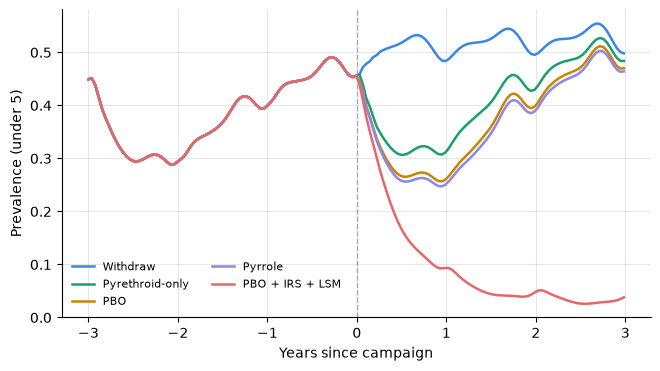

In [6]:
fig, ax = plt.subplots()

for _, row in results.iterrows():
    ax.plot(years, row["prevalence"], label=row["name"])

ax.axvline(0, color="#8b93a3", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Prevalence (under 5)")
ax.set_ylim(0, None)
ax.legend(ncol=2, fontsize=8)

plt.show()

The five lines coincide to the left of the grey dashed line. That is the shared run-up under the
pyrethroid-only nets already in place, and it is not flat, because prevalence has dynamics of its
own even when nothing changes. After the campaign the three net scenarios reduce prevalence, reach a
minimum roughly a year in, and converge towards one another as their insecticide decays, while the
blue withdrawal line rises throughout. The red combination scenario falls well below the other four
and stays there. This is because IRS and larval source management do not decay on the same
three-year clock a net does.

## Clinical cases

The same five scenarios carry a second trajectory, clinical incidence, on the emulator's own scale.

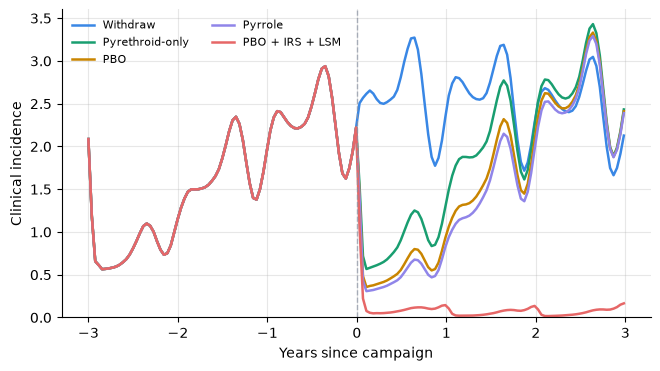

In [7]:
fig, ax = plt.subplots()

for _, row in results.iterrows():
    ax.plot(years, row["cases"], label=row["name"])

ax.axvline(0, color="#8b93a3", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Years since campaign")
ax.set_ylabel("Clinical incidence")
ax.set_ylim(0, None)
ax.legend(ncol=2, fontsize=8)

plt.show()

Incidence oscillates from one 14-day step to the next, far more than prevalence does, and by the
right-hand edge the three net scenarios have converged into a band that overlaps withdrawal. This is
because prevalence measures existing infection, while incidence records new episodes per step.
Incidence inherits the step's sampling noise.

## Tabulating the cases

`prev_endline` and `cases_endline` are single 14-day steps, cheap to sort on, and they throw away
the three years over which a campaign does its work.

In [8]:
results[["name", "cases_endline"]].sort_values("cases_endline").round(4)

,name,cases_endline
4,PBO + IRS + LSM,0.1653
0,Withdraw,2.1272
3,Pyrrole,2.3899
2,PBO,2.4124
1,Pyrethroid-only,2.4331


Sorted on `cases_endline` alone, withdrawing the nets comes out ahead of every net scenario, an
artefact of that single step rather than something the campaigns did. Add up the cases across every
step after the campaign instead. Measured against withdrawal, that total gives the cases each
campaign averts.

In [9]:
rows = []
for _, row in results.iterrows():
    cases_after = row["cases"][campaign_step:]              # every step from the campaign on
    rows.append({
        "name": row["name"],
        "total_cases": float(cases_after.sum()) * window,   # cases per 1000 over the period
    })

cases_table = pd.DataFrame(rows).set_index("name")

withdraw = cases_table.loc["Withdraw", "total_cases"]
cases_table["averted"] = withdraw - cases_table["total_cases"]
cases_table["averted_pct"] = 100 * cases_table["averted"] / withdraw

cases_table.sort_values("averted", ascending=False).round(1)

,total_cases,averted,averted_pct
name,,,
PBO + IRS + LSM,124.4,2671.7,95.6
Pyrrole,1692.3,1103.8,39.5
PBO,1789.8,1006.3,36.0
Pyrethroid-only,2083.4,712.7,25.5
Withdraw,2796.1,0.0,0.0


`cases` is on the emulator's own incidence scale, and because every scenario shares that scale, the
differences and percentages between them are meaningful without pinning the units. Totalled over the
three years the nets are in the field, the three net scenarios separate by around fourteen
percentage points of cases averted. At endline they were two prevalence points apart.

The ordering follows `dn0_future` and nothing else. It is therefore only as good as the resistance
level supplied, and a resistance estimate carries error. Re-run the scenarios across its plausible
range to see how much of the ordering survives it.

## Exporting

The frame `run_scenarios` returns does not travel as it stands, because two of its columns hold
NumPy arrays rather than numbers, and an array written into a CSV cell comes back as text. The
scalars and the trajectories need separate files. What the scalar file records is the derived
covariates and the outcomes, not the settings that were typed in.

In [10]:
os.makedirs("outputs", exist_ok=True)

summary = results.drop(columns=["prevalence", "cases"])
summary.to_csv("outputs/summary.csv", index=False)

summary.shape

(5, 21)

The trajectories want their own file in long form, one row per scenario per step, which is the shape
`ggplot2` and `dplyr` expect. Build a small frame for each scenario and paste them together with
`pd.concat`, so five scenarios of 157 steps is 785 rows.

In [11]:
frames = []
for _, row in results.iterrows():
    frames.append(pd.DataFrame({
        "name": row["name"],
        "day": day,
        "years": years,
        "prevalence": row["prevalence"],
        "cases": row["cases"],
    }))

trajectories = pd.concat(frames, ignore_index=True)
trajectories.to_csv("outputs/trajectories.csv", index=False)

print(trajectories.shape)
trajectories.head()

(785, 5)


,name,day,years,prevalence,cases
0,Withdraw,2190,-3.000000,0.449371,2.086377
1,Withdraw,2204,-2.961644,0.450827,1.185663
2,Withdraw,2218,-2.923288,0.438303,0.658037
3,Withdraw,2232,-2.884932,0.415712,0.613480
4,Withdraw,2246,-2.846575,0.393178,0.564645


`day` is the model's own clock and is what you would join on, while `years` is centred on the
campaign and is what you plot against. `index=False` suppresses pandas' row numbers, which would
otherwise arrive in R as a nameless leading column. On Colab the two files land under `outputs/` in
the file browser in the left-hand sidebar. They last as long as the session does.

Both files are plain CSV with a header row. R reads them straight back.

```r
library(readr)
library(ggplot2)

traj <- read_csv("outputs/trajectories.csv")

ggplot(traj, aes(x = years, y = prevalence, colour = name)) +
  geom_line(linewidth = 0.8) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(x = "Years since campaign", y = "Prevalence (under 5)", colour = NULL) +
  theme_minimal()
```

## See also

Please see [Running scenarios](https://cosmonaught.github.io/MINTverse/chapters/06-scenarios/run-scenarios.html)
for every field of `Scenario` and all twenty-three returned columns, and
[Trajectories and cases](https://cosmonaught.github.io/MINTverse/chapters/06-scenarios/comparing.html)
for the trajectories and the burden at greater length. [Nets and
dn0](https://cosmonaught.github.io/MINTverse/chapters/04-estimint/nets-and-dn0.html) covers the
resistance curves that set the ordering of the net scenarios, and [Covariates and the time
grid](https://cosmonaught.github.io/MINTverse/chapters/05-statemint/covariates.html) covers what the
emulator actually sees. [Troubleshooting](https://cosmonaught.github.io/MINTverse/chapters/troubleshooting.html)
is there when something does not work.